In [ ]:
from google.colab import drive
try:
  drive.mount('/content/drive')
  print("Kết nối thành công với gg drive")
except Exception as e:
  print(f"Đã xảy ra lỗi: {e}")

Mounted at /content/drive
Kết nối thành công với gg drive


[THÀNH CÔNG] Đã đọc dữ liệu cho: k=1
[THÀNH CÔNG] Đã đọc dữ liệu cho: k=3
[THÀNH CÔNG] Đã đọc dữ liệu cho: k=4
-----------------------------------------------------------------
METRIC               | k=1          | k=3          | k=4         
-----------------------------------------------------------------
MSE                  | 0.000000      | 0.000000      | 0.000000     
PSNR (dB)            | 106.8408        | 97.8881        | 92.7193       
SNR (dB)             | 83.0043        | 74.0510        | 68.8822       
Avg. Time (s)        | 3.9327        | 3.9797        | 2.8482       
-----------------------------------------------------------------


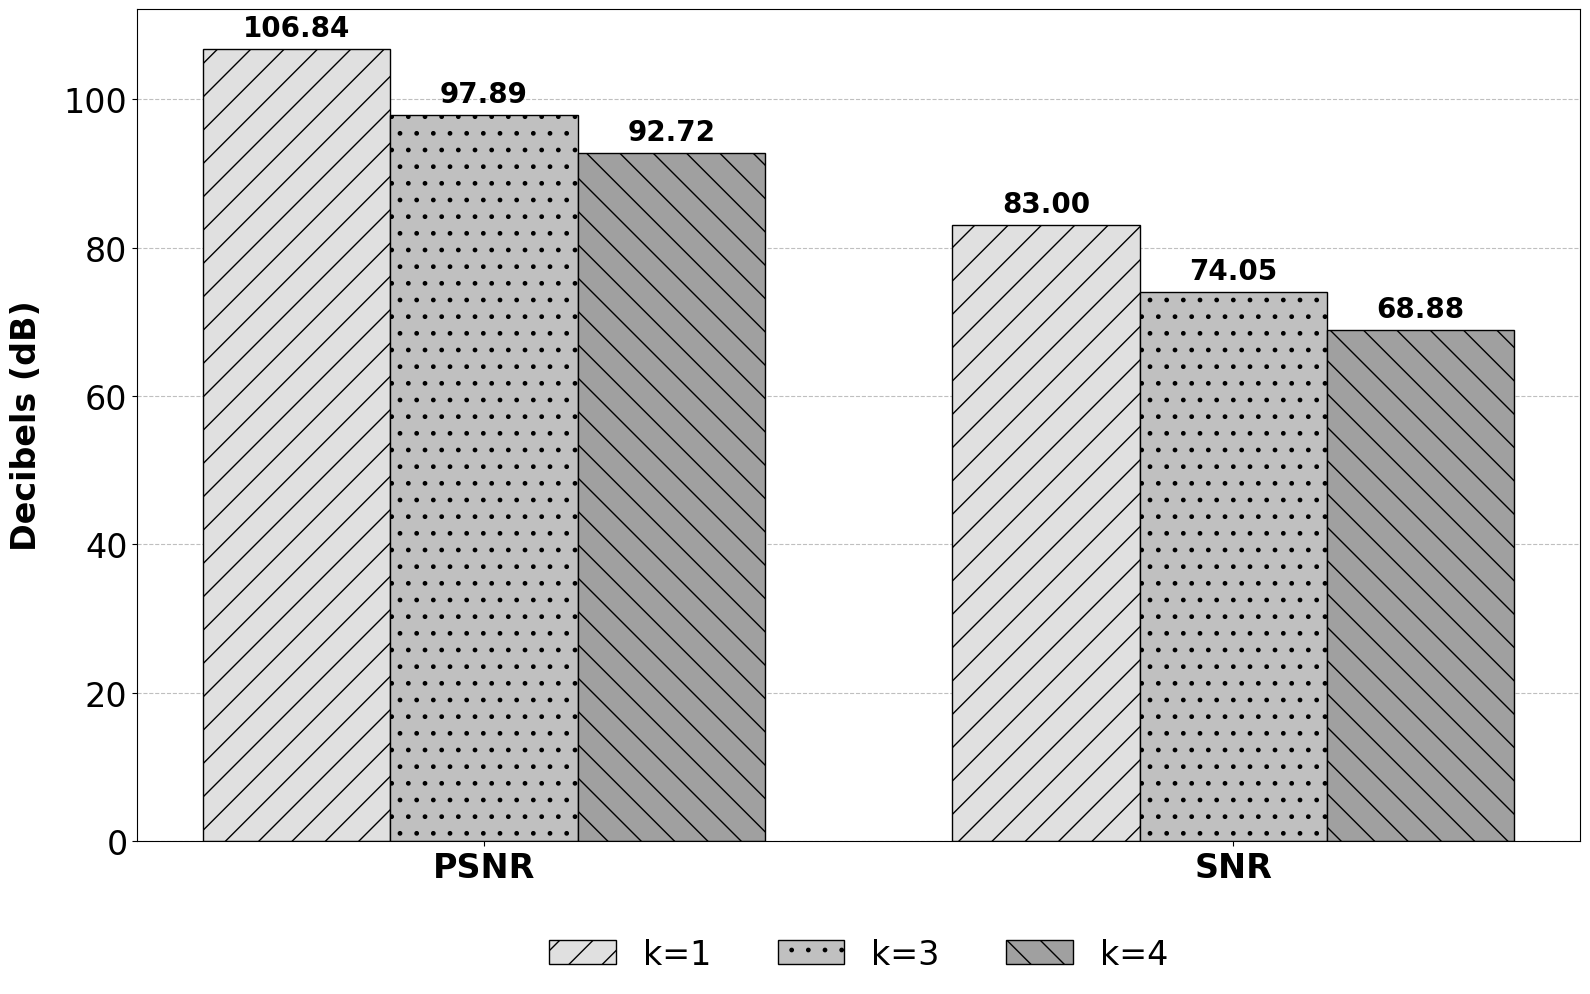

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Hàm xử lý riêng trường hợp tên file có dấu phẩy
def read_fixed_csv(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    # Kiểm tra xem file dùng tab hay dấu phẩy làm phân cách
    header = lines[0].strip('\n')
    if '\t' in header:
        return pd.read_csv(filepath, sep='\t') # Nếu dùng Tab thì dấu phẩy trong tên bài hát không gây lỗi

    # Nếu dùng dấu phẩy, xử lý thủ công
    data = []
    for line in lines:
        if not line.strip():
            continue

        parts = line.strip('\n').split(',')

        # File chuẩn có 11 cột. Nếu nhiều hơn 11, chắc chắn tên bài hát chứa dấu phẩy
        if len(parts) > 11:
            so_phan_thua = len(parts) - 11
            # Gộp lại phần tên bài hát bị tách nhầm (nằm từ index 1)
            ten_bai_hat_chuan = ','.join(parts[1:2 + so_phan_thua])

            # Lắp ráp lại dòng dữ liệu cho đúng 11 cột
            dong_da_sua = [parts[0], ten_bai_hat_chuan] + parts[2 + so_phan_thua:]
            data.append(dong_da_sua)
        else:
            data.append(parts)

    # Tạo DataFrame từ mảng dữ liệu đã sửa (dòng 0 là Header, các dòng sau là dữ liệu)
    df = pd.DataFrame(data[1:], columns=data[0])
    return df

# --- PHẦN CODE CHÍNH ---

files_map = {
    '/content/drive/MyDrive/Git-audio-stego/audio-steganograph/AudioStego/exp/logs/benchmark_local_input_5_Random_Adaptive_ContentSalt_20260615_170730.csv': 'k=1',
    '/content/drive/MyDrive/Git-audio-stego/audio-steganograph/AudioStego/exp/logs/benchmark_local_input_3_Random_Fixed_ContentSalt_20260618_081706_k=3.csv': 'k=3',
    '/content/drive/MyDrive/Git-audio-stego/audio-steganograph/AudioStego/exp/logs/benchmark_local_input_3_Random_Fixed_ContentSalt_20260618_091947_k=4.csv': 'k=4',
}

results = {}

for filename, method_name in files_map.items():
    if not os.path.exists(filename):
        print(f"[CẢNH BÁO] Không tìm thấy file: {filename}")
        continue

    try:
        # Sử dụng hàm tự viết để đọc file thay vì pd.read_csv thông thường
        df = read_fixed_csv(filename)

        df.columns = df.columns.str.strip()
        df_clean = df.iloc[:-1].copy()

        cols = ['MSE', 'PSNR', 'SNR', 'Time(s)']
        for col in cols:
            if col in df_clean.columns:
                df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

        avg_mse = df_clean['MSE'].mean() if 'MSE' in df_clean.columns else 0.0
        avg_psnr = df_clean['PSNR'].mean() if 'PSNR' in df_clean.columns else 0.0
        avg_snr = df_clean['SNR'].mean() if 'SNR' in df_clean.columns else 0.0
        avg_time = df_clean['Time(s)'].mean() if 'Time(s)' in df_clean.columns else 0.0

        results[method_name] = {
            'MSE': avg_mse,
            'PSNR (dB)': avg_psnr,
            'SNR (dB)': avg_snr,
            'Avg. Time (s)': avg_time
        }
        print(f"[THÀNH CÔNG] Đã đọc dữ liệu cho: {method_name}")

    except Exception as e:
        print(f"[LỖI] Xảy ra lỗi khi đọc file {filename}: {e}")

if results:
    methods = list(results.keys())  # ['k=1', 'k=3', 'k=4']

    # Header động theo methods thực tế
    header = f"{'METRIC':<20} | " + " | ".join(f"{m:<12}" for m in methods)
    print("-" * len(header))
    print(header)
    print("-" * len(header))

    metrics_order = ['MSE', 'PSNR (dB)', 'SNR (dB)', 'Avg. Time (s)']
    for metric in metrics_order:
        vals = [results.get(m, {}).get(metric, 0.0) for m in methods]
        if metric == 'MSE':
            row = " | ".join(f"{v:.6f}     " for v in vals)
        else:
            row = " | ".join(f"{v:.4f}       " for v in vals)
        print(f"{metric:<20} | {row}")
    print("-" * len(header))

    x = np.arange(len(plot_metrics))
    width = 0.25

    fig, ax = plt.subplots(figsize=(16, 10))

    colors = ['#e0e0e0', '#c0c0c0', '#a0a0a0']
    patterns = ['/', '.', '\\']

    for i, method in enumerate(methods):
        # Đảm bảo chỉ vẽ những methods có tồn tại để tránh lỗi List Index Out of Range
        if method in results:
            vals = [results[method][m] for m in plot_metrics]
            rects = ax.bar(x + (i - 1) * width, vals, width, label=method,
                           color=colors[i % len(colors)], edgecolor='black', hatch=patterns[i % len(patterns)])

            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.2f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 5), textcoords="offset points",
                            ha='center', va='bottom',
                            fontsize=20, fontweight='bold', color='black')

    FONT_SIZE = 24
    FONT_WEIGHT = 'bold'

    ax.set_ylabel('Decibels (dB)', fontsize=FONT_SIZE, fontweight=FONT_WEIGHT, labelpad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(['PSNR', 'SNR'], fontsize=FONT_SIZE, fontweight=FONT_WEIGHT)
    ax.tick_params(axis='y', labelsize=FONT_SIZE)

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')

    ax.legend(fontsize=FONT_SIZE, loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)

    plt.tight_layout()
    plt.savefig('Chart_Final_Clean.png', dpi=300)
    plt.show()
else:
    print("No data found. Vui lòng kiểm tra lại dòng CẢNH BÁO ở trên xem file có tồn tại không.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Paste đường dẫn file của bạn vào đây
path_lsb = '/content/drive/MyDrive/Git-audio-stego/audio-steganograph/Steganalysis/logs/MUSDB_LSB/Summary_CNN_20260207_093845.csv'
path_phase = '/content/drive/MyDrive/Git-audio-stego/audio-steganograph/Steganalysis/logs/MUSDB_Phase_CNN/Summary_CNN_20260207_094103.csv'
path_improved = '/content/drive/MyDrive/Git-audio-stego/audio-steganograph/Steganalysis/logs/MUSDB_LSB_5_Random_Adaptive_ContentSalt/Summary_CNN_20260207_105815.csv'

files_map = {
    'LSB-Based': path_lsb,
    'Phase Coding': path_phase,
    'Improved LSB': path_improved
}

# Mapping tên cột trong CSV -> Tên hiển thị
metrics_mapping = {
    'Val_Acc': 'Accuracy',
    'Precision': 'Precision',
    'Recall': 'Recall',
    'F1': 'F1-Score'
}


results = {}

print("--- ĐANG ĐỌC DỮ LIỆU ---")

for method_name, filepath in files_map.items():
    if not os.path.exists(filepath):
        print(f" [!] Bỏ qua (Không tìm thấy): {method_name}")
        continue

    try:
        df = pd.read_csv(filepath)
        df.columns = df.columns.str.strip()

        # Dictionary lưu chỉ số của phương pháp này
        method_metrics = {}

        for raw_metric, display_name in metrics_mapping.items():
            # Tìm dòng chứa Metric
            row = df[df['Metric'].astype(str).str.contains(raw_metric, case=False, na=False)]
            if not row.empty:
                val = row['Mean'].values[0]
                method_metrics[display_name] = val
            else:
                method_metrics[display_name] = 0.0

        results[method_name] = method_metrics
        print(f" [OK] {method_name}")

    except Exception as e:
        print(f" [ERR] {method_name}: {e}")


if results:
    print("\n" + "="*60)
    print(f"{'METRIC':<15} | {'LSB-Based':<12} | {'Phase Coding':<12} | {'Improved LSB':<12}")
    print("="*60)

    # Duyệt qua từng chỉ số để in dòng
    display_metrics = list(metrics_mapping.values()) # ['Accuracy', 'Precision', ...]

    for m in display_metrics:
        v1 = results.get('LSB-Based', {}).get(m, 0.0)
        v2 = results.get('Phase Coding', {}).get(m, 0.0)
        v3 = results.get('Improved LSB', {}).get(m, 0.0)
        print(f"{m:<15} | {v1:.4f}       | {v2:.4f}       | {v3:.4f}")
    print("="*60 + "\n")

if results:
    labels = list(metrics_mapping.values())
    x = np.arange(len(labels))
    width = 0.25

    # Tăng kích thước hình để chứa font to
    fig, ax = plt.subplots(figsize=(22, 12))

    # --- STYLE GRAYSCALE + HATCHING ---
    colors = ['#e0e0e0', '#c0c0c0', '#a0a0a0'] # Xám nhạt -> Đậm dần
    patterns = ['/', '.', '\\']                # Gạch chéo, Chấm, Gạch ngược

    draw_order = ['LSB-Based', 'Phase Coding', 'Improved LSB']

    for i, method in enumerate(draw_order):
        if method in results:
            # Lấy list giá trị theo đúng thứ tự nhãn
            vals = [results[method][label] for label in labels]

            # Vẽ cột
            rects = ax.bar(x + (i - 1) * width, vals, width, label=method,
                           color=colors[i], edgecolor='black', hatch=patterns[i])

            # Hiển thị số trên cột (Font 20)
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.2f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 10), textcoords="offset points",
                            ha='center', va='bottom',
                            fontsize=28, fontweight='bold', color='black')

    # --- CẤU HÌNH FONT SIZE 24 ---
    FONT_SIZE = 28
    FONT_WEIGHT = 'bold'

    ax.set_ylabel('Value (0.0 - 1.0)', fontsize=FONT_SIZE, fontweight=FONT_WEIGHT, labelpad=20)

    # Nếu muốn hiện tiêu đề thì bỏ comment dòng dưới
    # ax.set_title('CNN Detection Performance', fontsize=28, fontweight=FONT_WEIGHT, pad=30)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=FONT_SIZE, fontweight=FONT_WEIGHT)
    ax.tick_params(axis='y', labelsize=FONT_SIZE)

    # Lưới ngang
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
    ax.set_ylim(0, 1.15) # Tăng chiều cao trục Y để số không bị cắt

    # Chú thích (Legend)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08),
              ncol=3, fontsize=FONT_SIZE, frameon=False)

    plt.tight_layout()
    output_filename = 'Chart_CNN_Performance_OldStyle.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[HOÀN TẤT] Biểu đồ đã lưu tại: {output_filename}")

else:
    print("[!] Không có dữ liệu để vẽ.")

--- ĐANG ĐỌC DỮ LIỆU ---
 [!] Bỏ qua (Không tìm thấy): LSB-Based
 [!] Bỏ qua (Không tìm thấy): Phase Coding
 [!] Bỏ qua (Không tìm thấy): Improved LSB
[!] Không có dữ liệu để vẽ.


-----------------------------------------------------------------
METRIC               | 128          | 256          | 512         
-----------------------------------------------------------------
MSE                  | 0.000000     | 0.000000     | 0.000000    
PSNR (dB)            | 98.6580      | 94.8508      | 83.6729     
SNR (dB)             | 61.1555      | 57.3485      | 46.1705     
Rate (kBps)          | 0.5828       | 1.3829       | 3.9386      
Avg. Time (s)        | 0.6789       | 0.6961       | 0.6953      
-----------------------------------------------------------------


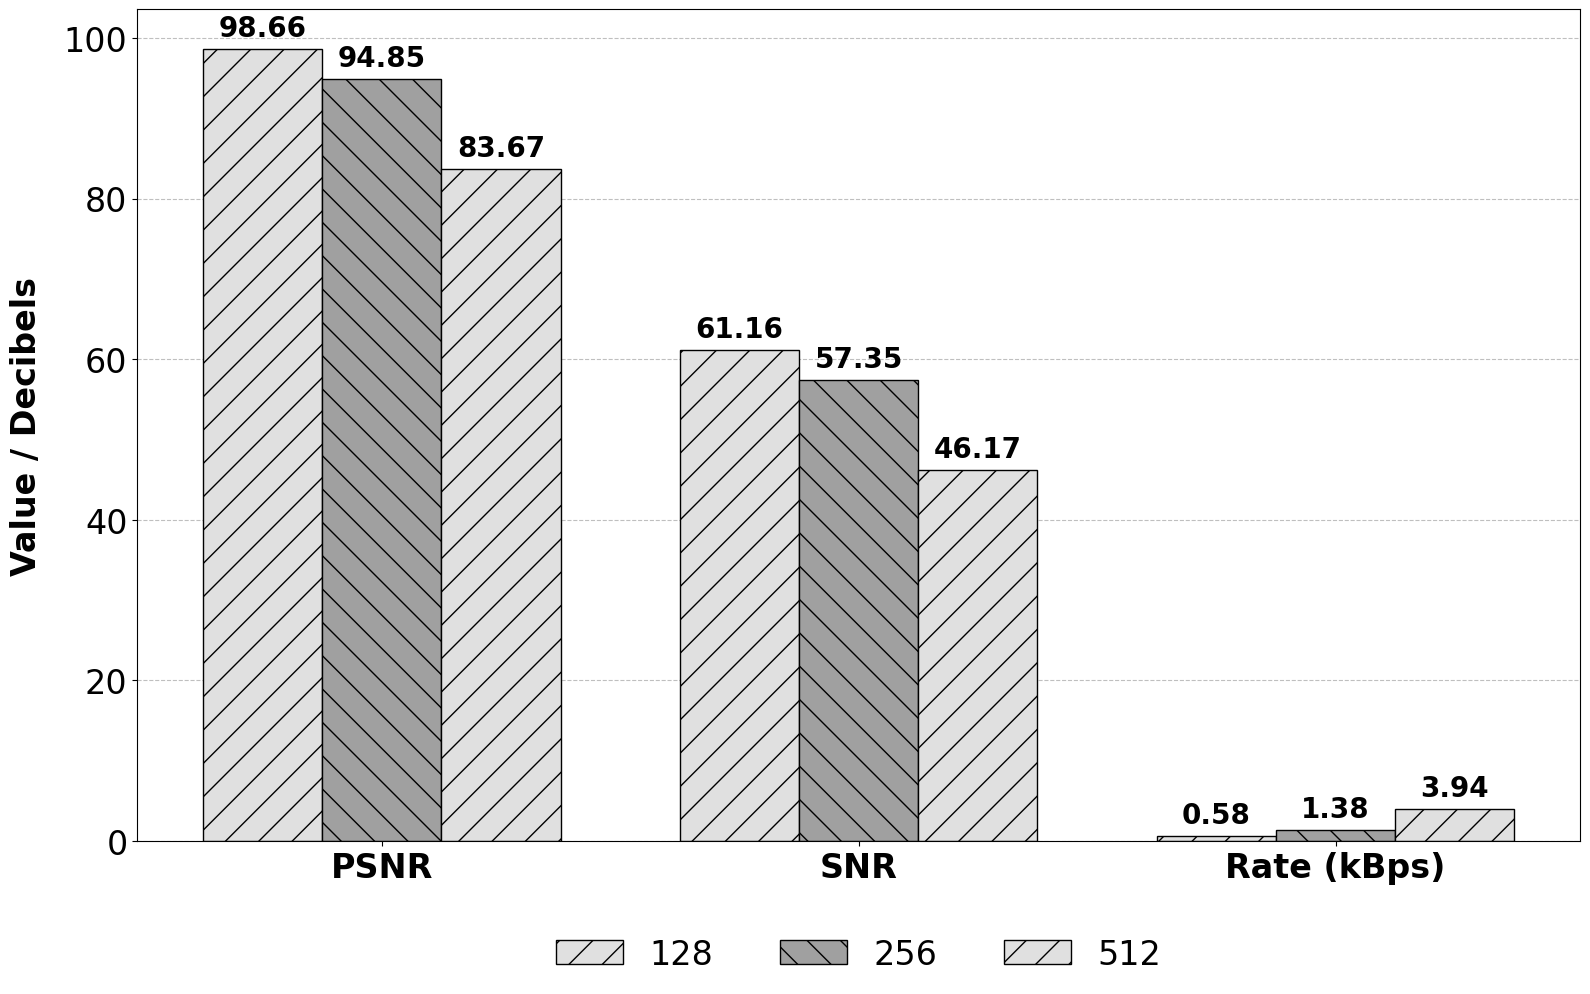

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

files_map = {
    '/content/drive/MyDrive/HK1-20252026/Steganography/RUN-TIMIT/Timit_voc_500_128_20/5_Random_Adaptive_ContentSalt_20260621_013041/logs/benchmark.csv': '128',
    '/content/drive/MyDrive/HK1-20252026/Steganography/RUN-TIMIT/Timit_voc_500_256_20/5_Random_Adaptive_ContentSalt_20260621_014259/logs/benchmark.csv': '256',
    '/content/drive/MyDrive/HK1-20252026/Steganography/RUN-TIMIT/Timit_voc_500_512_20/5_Random_Adaptive_ContentSalt_20260621_011044/logs/benchmark.csv': '512'

}

results = {}

for filename, method_name in files_map.items():
    if not os.path.exists(filename):
        continue
    try:
        try:
            df = pd.read_csv(filename, sep='\t')
            if len(df.columns) < 2: raise ValueError
        except:
            df = pd.read_csv(filename, sep=',')

        df.columns = df.columns.str.strip()

        cols = ['MSE', 'PSNR', 'SNR', 'Time(s)', 'Rate(kBps)']
        for col in cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        avg_mse = df['MSE'].mean() if 'MSE' in df.columns else 0.0
        avg_psnr = df['PSNR'].mean() if 'PSNR' in df.columns else 0.0
        avg_snr = df['SNR'].mean() if 'SNR' in df.columns else 0.0
        avg_time = df['Time(s)'].mean() if 'Time(s)' in df.columns else 0.0
        avg_rate = df['Rate(kBps)'].mean() if 'Rate(kBps)' in df.columns else 0.0

        results[method_name] = {
            'MSE': avg_mse,
            'PSNR (dB)': avg_psnr,
            'SNR (dB)': avg_snr,
            'Rate (kBps)': avg_rate,
            'Avg. Time (s)': avg_time
        }

    except Exception:
        pass

if results:
    print("-" * 65)
    headers = list(results.keys())
    header_str = f"{'METRIC':<20} | " + " | ".join([f"{h:<12}" for h in headers])
    print(header_str)
    print("-" * 65)

    metrics_order = ['MSE', 'PSNR (dB)', 'SNR (dB)', 'Rate (kBps)', 'Avg. Time (s)']

    for m in metrics_order:
        row_vals = []
        for h in headers:
            val = results.get(h, {}).get(m, 0.0)
            if m == 'MSE':
                row_vals.append(f"{val:.6f}")
            else:
                row_vals.append(f"{val:.4f}")

        row_str = f"{m:<20} | " + " | ".join([f"{v:<12}" for v in row_vals])
        print(row_str)
    print("-" * 65)

    methods = list(results.keys())
    plot_metrics = ['PSNR (dB)', 'SNR (dB)', 'Rate (kBps)']

    x = np.arange(len(plot_metrics))
    width = 0.25

    fig, ax = plt.subplots(figsize=(16, 10))

    colors = ['#e0e0e0', '#a0a0a0']
    patterns = ['/', '\\']

    num_methods = len(methods)

    for i, method in enumerate(methods):
        vals = [results[method][m] for m in plot_metrics]
        offset = (i - (num_methods - 1) / 2) * width

        rects = ax.bar(x + offset, vals, width, label=method,
                       color=colors[i % len(colors)],
                       edgecolor='black',
                       hatch=patterns[i % len(patterns)])

        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5), textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=20, fontweight='bold', color='black')

    FONT_SIZE = 24
    FONT_WEIGHT = 'bold'

    ax.set_ylabel('Value / Decibels', fontsize=FONT_SIZE, fontweight=FONT_WEIGHT, labelpad=15)

    ax.set_xticks(x)
    x_labels = ['PSNR', 'SNR', 'Rate (kBps)']
    ax.set_xticklabels(x_labels, fontsize=FONT_SIZE, fontweight=FONT_WEIGHT)

    ax.tick_params(axis='y', labelsize=FONT_SIZE)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')

    ax.legend(fontsize=FONT_SIZE, loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=num_methods, frameon=False)

    plt.tight_layout()
    plt.savefig('Chart_Final_With_Rate.png', dpi=300)
    plt.show()
else:
    print("No data found.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Paste đường dẫn file của bạn vào đây
path_lsb = '/content/drive/MyDrive/Git-audio-stego/audio-steganograph/Steganalysis/logs/MUSDB_LSB/Summary_CNN_20260207_093845.csv'
path_phase = '/content/drive/MyDrive/Git-audio-stego/audio-steganograph/Steganalysis/logs/MUSDB_Phase_CNN/Summary_CNN_20260207_094103.csv'
path_improved = '/content/drive/MyDrive/Git-audio-stego/audio-steganograph/Steganalysis/logs/MUSDB_LSB_5_Random_Adaptive_ContentSalt/Summary_CNN_20260207_105815.csv'

files_map = {
    'LSB-Based': path_lsb,
    'Phase Coding': path_phase,
    'Improved LSB': path_improved
}

# Mapping tên cột trong CSV -> Tên hiển thị
metrics_mapping = {
    'Val_Acc': 'Accuracy',
    'Precision': 'Precision',
    'Recall': 'Recall',
    'F1': 'F1-Score'
}


results = {}

print("--- ĐANG ĐỌC DỮ LIỆU ---")

for method_name, filepath in files_map.items():
    if not os.path.exists(filepath):
        print(f" [!] Bỏ qua (Không tìm thấy): {method_name}")
        continue

    try:
        df = pd.read_csv(filepath)
        df.columns = df.columns.str.strip()

        # Dictionary lưu chỉ số của phương pháp này
        method_metrics = {}

        for raw_metric, display_name in metrics_mapping.items():
            # Tìm dòng chứa Metric
            row = df[df['Metric'].astype(str).str.contains(raw_metric, case=False, na=False)]
            if not row.empty:
                val = row['Mean'].values[0]
                method_metrics[display_name] = val
            else:
                method_metrics[display_name] = 0.0

        results[method_name] = method_metrics
        print(f" [OK] {method_name}")

    except Exception as e:
        print(f" [ERR] {method_name}: {e}")


if results:
    print("\n" + "="*60)
    print(f"{'METRIC':<15} | {'LSB-Based':<12} | {'Phase Coding':<12} | {'Improved LSB':<12}")
    print("="*60)

    # Duyệt qua từng chỉ số để in dòng
    display_metrics = list(metrics_mapping.values()) # ['Accuracy', 'Precision', ...]

    for m in display_metrics:
        v1 = results.get('LSB-Based', {}).get(m, 0.0)
        v2 = results.get('Phase Coding', {}).get(m, 0.0)
        v3 = results.get('Improved LSB', {}).get(m, 0.0)
        print(f"{m:<15} | {v1:.4f}       | {v2:.4f}       | {v3:.4f}")
    print("="*60 + "\n")

if results:
    labels = list(metrics_mapping.values())
    x = np.arange(len(labels))
    width = 0.25

    # Tăng kích thước hình để chứa font to
    fig, ax = plt.subplots(figsize=(22, 12))

    # --- STYLE GRAYSCALE + HATCHING ---
    colors = ['#e0e0e0', '#c0c0c0', '#a0a0a0'] # Xám nhạt -> Đậm dần
    patterns = ['/', '.', '\\']                # Gạch chéo, Chấm, Gạch ngược

    draw_order = ['LSB-Based', 'Phase Coding', 'Improved LSB']

    for i, method in enumerate(draw_order):
        if method in results:
            # Lấy list giá trị theo đúng thứ tự nhãn
            vals = [results[method][label] for label in labels]

            # Vẽ cột
            rects = ax.bar(x + (i - 1) * width, vals, width, label=method,
                           color=colors[i], edgecolor='black', hatch=patterns[i])

            # Hiển thị số trên cột (Font 20)
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.2f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 10), textcoords="offset points",
                            ha='center', va='bottom',
                            fontsize=28, fontweight='bold', color='black')

    # --- CẤU HÌNH FONT SIZE 24 ---
    FONT_SIZE = 28
    FONT_WEIGHT = 'bold'

    ax.set_ylabel('Value (0.0 - 1.0)', fontsize=FONT_SIZE, fontweight=FONT_WEIGHT, labelpad=20)

    # Nếu muốn hiện tiêu đề thì bỏ comment dòng dưới
    # ax.set_title('CNN Detection Performance', fontsize=28, fontweight=FONT_WEIGHT, pad=30)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=FONT_SIZE, fontweight=FONT_WEIGHT)
    ax.tick_params(axis='y', labelsize=FONT_SIZE)

    # Lưới ngang
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
    ax.set_ylim(0, 1.15) # Tăng chiều cao trục Y để số không bị cắt

    # Chú thích (Legend)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08),
              ncol=3, fontsize=FONT_SIZE, frameon=False)

    plt.tight_layout()
    output_filename = 'Chart_CNN_Performance_OldStyle.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[HOÀN TẤT] Biểu đồ đã lưu tại: {output_filename}")

else:
    print("[!] Không có dữ liệu để vẽ.")